# Taller MIAX — Deep Portfolios con Autoencoders
## Replicar el S&P 500 Equal Weight con 25 acciones elegidas por una red neuronal

> **Dónde encaja este taller.** De todo lo visto en teoría, aquí nos centramos en un
> **ejemplo concreto de uso de embeddings en mercados financieros**: comprimir el
> comportamiento de cada acción en un *embedding* y explotarlo —de principio a fin—
> para replicar un índice.

**El reto.** Construir un *tracker sparse*: una cartera de **solo 25 acciones** que
replique el comportamiento del **S&P 500 Equal Weight** (≈ ETF **RSP**, de unas 500
acciones). Gana el equipo cuyo tracker siga al índice con **menor tracking error**
fuera de muestra.

**La vuelta de tuerca:** no elegís las 25 acciones a mano. Las elige un
**autoencoder que vosotros diseñáis**. La competición no se gana construyendo
carteras — se gana construyendo el mejor autoencoder.

### Cómo funciona
1. Entrenáis un autoencoder sobre los **retornos** de las acciones del universo (train **2015–2021**).
2. El **encoder** proyecta cada acción a un **espacio latente** de pocas dimensiones.
3. Un procedimiento **fijo y común** agrupa las acciones en 25 grupos, toma un
   representante por grupo y asigna pesos por tamaño de grupo → vuestro tracker.
4. La webapp calcula el **tracking error** y ordena el leaderboard.

Los pasos 2–4 están cerrados e iguales para todos. **Vosotros solo cambiáis el
autoencoder del paso 1.**

### Reglas (resumen)
- **Validación 2022–2023:** iteráis **sin límite**; es vuestro campo de pruebas para
  testear los modelos y el leaderboard en vivo se basa en ella.
- **Test 2024–2025:** el juez real. **Una única evaluación final** con el modelo
  congelado (irreversible) al cierre. El ranking final se decide en test.
- **Métrica:** *Score = Tracking Error out-of-sample*. Nº de acciones fijo (25).
- Reenviar sin parar mirando validación **es sobreajustar a validación** — el error que este máster enseña a evitar.

## 1. Setup

Necesitas dos cosas de tu **panel de grupo** en la webapp:
- `API_URL`: la URL del endpoint de datos del taller.
- `TOKEN`: tu **token de grupo** (autentica la descarga de datos y el envío). No es tu contraseña.

> El token identifica a tu grupo. No lo compartas: cualquiera con él puede enviar en tu nombre.

In [12]:
import sys, os, random
import numpy as np
import pandas as pd

# El andamiaje vive en utils/ (mismo código que el servidor para selección/TE).
sys.path.insert(0, os.path.join(os.getcwd(), "utils"))
import data_loader as dl
import tracking_error as te
from selection import select_tracker          # procedimiento de selección FIJO
import submit as submit_mod

# --- Configuración del grupo (cópialo de tu panel web) ---
API_URL = "https://miaxtallerautoencoders-production.up.railway.app"
TOKEN   = ""  # REDACTED: set MIAX_AE_TOKEN instead

# --- Semilla OFICIAL fija: NO la cambies ---
# Todos entrenais con SEED = 42 (reproducibilidad y juego limpio). Si la cambias, la
# entrega sera RECHAZADA en validacion Y en test (lo comprueban el notebook y el
# servidor). Lo unico que os diferencia es vuestro autoencoder.
SEED = 42
random.seed(SEED); np.random.seed(SEED)

## 2. Carga de datos

Descargamos los datos directamente de la webapp con tu token. Recibes **solo
train + validación** — el periodo de **test no sale nunca del servidor** (así nadie
puede ajustar a él).

**Universo (importante).** Son las acciones presentes en el S&P 500 **durante toda
la ventana de entrenamiento**, con histórico completo. Es un panel *rectangular* y
limpio. Esto introduce, a propósito, un **sesgo de supervivencia** (solo
sobreviven las que siguieron en el índice) — lo discutimos abajo.

In [13]:
data = dl.load_all(API_URL, TOKEN)
meta        = data["metadata"]
prices_wide = data["prices_wide"]   # precios ajustados (fecha × ticker)
rsp         = data["benchmark"]     # serie RSP (Adj Close / total return)

tickers = meta["universe"]
train_w = meta["windows"]["train"]
val_w   = meta["windows"]["validation"]
print(f"Universo: {len(tickers)} acciones | Train {train_w['start']}..{train_w['end']} | Val {val_w['start']}..{val_w['end']}")
print(f"Target: {meta['target']['name']} — {meta['target']['note']}")
prices_wide.tail(3)

Universo: 342 acciones | Train 2015-01-01..2021-12-31 | Val 2022-01-01..2023-12-31
Target: RSP — Invesco S&P 500 Equal Weight ETF (Adj Close / total return)


symbol,A,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WY,WYNN,XEL,XOM,XRAY,XYL,YUM,ZBH,ZION,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2023-12-27,137.515076,191.342957,143.217712,105.107750,339.121307,596.080017,192.844421,67.040558,221.719955,245.110001,...,32.661800,88.782867,57.392315,94.826370,32.977139,111.795563,125.850578,118.921959,41.522583,191.593918
2023-12-28,137.465897,191.768951,143.097504,105.691742,336.983948,595.520020,193.705383,67.133446,222.562378,244.910004,...,32.981277,89.889839,57.718727,93.455177,33.070057,111.736923,125.542786,119.412849,41.662518,191.846924
2023-12-29,136.969360,190.728760,143.300934,105.375809,336.332184,596.599976,192.080200,67.087006,223.021881,243.479996,...,32.671200,89.253082,57.737377,93.259300,33.070057,111.776016,125.677452,119.481567,40.925537,192.051254


## 3. El benchmark (RSP) y el *suelo* irreducible de tracking error

> **El tracking error nunca llegará a cero, y no será culpa de vuestro
> autoencoder.** Hay un **error irreducible idéntico para todos**. Vuestro trabajo
> es acercaros a ese suelo mejor que nadie.

Comparamos el **Equal-Weight de nuestro universo** (≈342 acciones, **rebalanceo
trimestral** como RSP) con **RSP** real. Estos números los hemos medido en servidor
(incluyen el test que vosotros no veis):

| Ventana | Tracking error | Correlación | CAGR univ. | CAGR RSP | Vol univ. | Vol RSP | MaxDD univ. | MaxDD RSP |
|---|---|---|---|---|---|---|---|---|
| Train 2015–2021 | 1.65 % | 0.996 | 15.4 % | 12.6 % | 19.2 % | 19.0 % | −39.7 % | −39.0 % |
| Valid 2022–2023 | 2.16 % | 0.994 |  3.0 % |  0.3 % | 18.7 % | 19.0 % | −20.3 % | −21.4 % |
| Test 2024–2025  | 1.82 % | 0.992 | 15.5 % | 12.1 % | 14.5 % | 14.6 % | −16.8 % | −17.8 % |

### ¿Por qué el TE nunca es 0? (de dónde sale el suelo de ~2 %)
- **Composición del universo (≈342 vs ≈500 de RSP)** — *causa dominante*. Nos
  faltan ~160 miembros (más pequeños/recientes); el co-movimiento diario difiere.
- **Rebalanceo:** replicamos el esquema de RSP (**trimestral**), así que esta fuente
  de error prácticamente desaparece; solo queda un residuo por no rebalancear
  exactamente en las mismas fechas que el índice.
- **Mecánica real del ETF:** costes de transacción de *sus* rebalanceos, *cash
  drag*, muestreo/optimización, timing de reinversión de dividendos.
- **Comisión del ETF (~0.20 %/año):** arrastre casi constante; afecta sobre todo al
  *nivel* (CAGR), poco al TE.

A esto, **vuestro tracker añade su propio TE**: usa solo **25 acciones** (no 342/500)
y depende de la **calidad de vuestro autoencoder**. Ahí es donde se compite.

### ¿Por qué el CAGR del universo es tan superior al de RSP (≈ +3 pp)?
- **Sesgo de supervivencia** — *causa dominante*: nuestras acciones son las que
  **sobrevivieron** en el índice (ganadoras); las que cayeron o salieron no están.
- **Comisión del ETF** (RSP paga ~0.20 %/año; el universo teórico, no) → ensancha la brecha.
- **Universo incompleto** (menos nombres para promediar).

Fíjate en el matiz: la **vol y el max drawdown son casi idénticos** y la
**correlación ~0.99** — el sesgo de supervivencia mueve el *nivel de retorno*, **no
el riesgo ni el seguimiento**. Como la competición puntúa por **TE** (no por
retorno), este sesgo es el mismo suelo para todos y **no falsea el ranking**.

### ¿Por qué el CAGR de validación (2022–2023) es tan bajo frente a train/test? ¿Es un problema?
**No es un problema — al contrario.** **2022 fue un año bajista** (subida de tipos)
y 2023 apenas lo recuperó, así que 2022–2023 quedó casi plano. Es un **régimen de
mercado distinto** al de train (2015–2021, mayormente alcista). Esto es **deseable**:
- La **correlación con RSP es ~0.99 en *todos* los años**, incluido 2022, y el TE se
  mantiene ~2 %: la **calidad de seguimiento es estable** aunque el retorno cambie.
- El autoencoder aprende la **estructura transversal** (qué acciones co-mueven), no
  el nivel de retorno — y esa estructura es estable entre regímenes.
- Que validación sea un régimen **diferente** a train la convierte en una prueba
  **real de generalización**: si todo fuera el mismo mercado alcista fácil, el
  sobreajuste no se penalizaría. Por eso normalizaremos el AE con estadísticas de
  **train** y no reajustaremos en validación.

### Retorno anual de RSP (Total Return) en el histórico

Para que tengáis contexto del régimen de mercado de cada periodo:

| Año | RSP (Total Return) |  | Año | RSP (Total Return) |
|---|---|---|---|---|
| 2012 | +15.39 % | | 2019 | +28.91 % |
| 2013 | +35.54 % | | 2020 | +12.66 % |
| 2014 | +14.06 % | | 2021 | +29.41 % |
| 2015 | −2.67 % | | 2022 | **−11.62 %** |
| 2016 | +14.50 % | | 2023 | +13.70 % |
| 2017 | +18.52 % | | 2024 | +12.79 % |
| 2018 | −7.84 % | | 2025 | +11.21 % |

**CAGR 2012–2025: 12.44 %** (acumulado +414 %). Años negativos: 2015, 2018 y, el
peor, **2022** — por eso la validación (2022–2023) es un régimen distinto al de
train, y un buen test de generalización.

### Definición de las métricas (fórmulas)

Estas son **todas** las métricas que usamos. $P_t$ = precio ajustado; $r_t$ =
retorno diario; $n$ = nº de días; 252 = días de bolsa al año.

**Retorno simple diario**
$$ r_t = \frac{P_t}{P_{t-1}} - 1 $$
Variación porcentual diaria del precio (ajustado por dividendos/splits).

**Retorno diario del tracker** (cartera con **rebalanceo trimestral**, como RSP)
$$ r_t^{\text{track}} = \sum_{i=1}^{N} w_{i,t}\, r_{i,t}, \qquad \sum_{i} w_i = 1 $$
Media ponderada de los retornos de las acciones. Los pesos objetivo $w_i$ se
**reajustan al inicio de cada trimestre natural** y entre medias se dejan derivar con
los precios (*buy-and-hold*), por lo que el peso efectivo $w_{i,t}$ varía dentro del
trimestre. Replica la mecánica real de RSP (que rebalancea cada trimestre) y es
**idéntico en el notebook y en el servidor**.

**Tracking Error (anualizado)** — *la métrica de la competición*
$$ \mathrm{TE} = \sqrt{252}\;\sigma\!\big(r_t^{\text{track}} - r_t^{\text{bench}}\big) $$
Desviación típica de la diferencia diaria de retornos frente al benchmark (RSP).
**Menor = mejor seguimiento.** Mide la calidad de tu latente.

**Correlación** (Pearson de los retornos diarios)
$$ \rho = \frac{\operatorname{cov}\!\big(r^{\text{track}}, r^{\text{bench}}\big)}{\sigma(r^{\text{track}})\,\sigma(r^{\text{bench}})} $$
Co-movimiento direccional ($-1$ a $1$); $\approx 1$ = se mueven juntos. Puede haber
correlación alta y TE no nulo (difieren en *magnitud*, no en dirección).

**CAGR** (tasa de crecimiento anual compuesta)
$$ \mathrm{CAGR} = \left(\prod_{t=1}^{n}(1+r_t)\right)^{\!252/n} - 1 $$
Rendimiento medio anualizado compuesto del periodo. Mide **retorno**, no riesgo.

**Volatilidad anualizada**
$$ \sigma_{\text{ann}} = \sqrt{252}\;\sigma(r_t) $$
Dispersión de los retornos diarios escalada a un año. Proxy de **riesgo**.

**Máximo drawdown**
$$ W_t = \prod_{s=1}^{t}(1+r_s), \qquad \mathrm{MaxDD} = \min_t\!\left(\frac{W_t}{\max_{u\le t} W_u} - 1\right) $$
Peor caída acumulada desde un máximo previo (valor negativo): la mayor pérdida que
habrías soportado.

> Nota: usamos desviación típica **muestral** ($\sigma$ con $n-1$ grados de libertad).

### Cómo se puntúa la práctica (nota 0–100)

El leaderboard ordena por **tracking error**, pero tu **nota** se arma por partes (tope **100**):

| Concepto | Puntos |
|---|---|
| ✅ **Entrega correcta** — un envío final válido y coherente | **50** |
| 🏆 **Bates a PCA** — tu TE de test baja del competidor fantasma | **70** |
| 🐒 **Percentil frente a los monos** en test — cuanto mejor, más | **+20** |
| 🥇 **Podio en test** — 1º **+10**, 2º y 3º **+5** | **+10 / +5** |

El máximo cuadra justo: 70 (bates a PCA) + 20 (bates a los monos) + 10 (1º) = **100**.

Además, el profesor puede dar un **bonus de participación** en clase (según el ranking):
🥇 +25 · 🥈 +20 · 🥉 +15 · 4º–10º +10. Pero **la nota final nunca pasa de 100**.

**Los monos (ese +20) no son ingenuos — son *sectoriales*.** Un mono de 25 acciones **uniformes
al azar** carga por casualidad sectores enteros (p.ej. 8 tecnológicas) y traquea
fatal, así que batirlo sería trivial. Para que el listón sea **justo y exigente**,
cada mono se construye así:

1. **Reparto por sector**: las 25 plazas se reparten entre los sectores del universo
   **en proporción a su tamaño** (mayor resto). Con el universo actual: 4 financieras,
   4 industriales, 3 de consumo discrecional, 3 de salud, 3 tecnológicas, 2 de consumo
   básico, 2 utilities, y 1 de materiales, inmobiliario, energía y comunicaciones.
2. **Aleatorio dentro de cada sector**: se eligen al azar esas acciones dentro de cada
   sector.
3. **Equiponderado** (1/25) y con el **mismo rebalanceo trimestral** y la misma
   definición de TE que tu modelo.

Así el mono queda **diversificado como el índice** y compites contra un aleatorio
razonable. **Consecuencia práctica:** un autoencoder con un latente enorme que
*sobreajusta* puede que **ni siquiera bata a estos monos** — la nota lo delata.

In [14]:
# Comprobación EN VIVO con tus datos (train+val): EW del universo vs RSP.
ew_weights = {t: 1.0 / len(tickers) for t in tickers}
ew_returns = te.portfolio_returns(prices_wide, ew_weights)
rsp_returns = te.to_returns(rsp)

def in_window(s, w):
    return s[(s.index >= pd.Timestamp(w["start"])) & (s.index <= pd.Timestamp(w["end"]))]

print("== Equal-Weight del universo vs RSP — VALIDACIÓN ==")
display(te.summary_frame(in_window(ew_returns, val_w), in_window(rsp_returns, val_w),
                         tracker_name="EW universo"))

== Equal-Weight del universo vs RSP — VALIDACIÓN ==


,EW universo,RSP
CAGR,2.92%,0.25%
Vol. anualizada,18.48%,18.98%
Máx. drawdown,-20.17%,-21.38%
Tracking error,2.16%,
Correlación,0.994,
Días,501,


## 4. Construye tu autoencoder  ⟵ **AQUÍ SE COMPITE**

Lo **único** que tocáis. El esqueleto fija **entrada y salida** (dimensión =
número de días de retorno por acción). Vosotros decidís todo lo de dentro:

- **Profundidad y anchura** (capas y neuronas).
- **Dimensión del cuello de botella** — la decisión estrella: ¿cuántos factores
  latentes? Pocos pierde estructura; demasiados no comprime.
- **Activaciones** y **regularización** (sparse, denoising, dropout, L1/L2…).

> **Ojo:** la *dimensión latente* (factores que usa la red para describir cada
> acción) y el *número de acciones del tracker* (fijo en 25) son cosas distintas.
> Podéis usar 3 o 9 factores y, sobre esa nube, seguir eligiendo 25 representantes.

### Tratamiento de los datos para el autoencoder

- **Qué entra**: partimos de **precios ajustados** (por dividendos y splits) y
  calculamos **retornos simples (aritméticos) diarios** $r_t = P_t/P_{t-1}-1$ — **no**
  logarítmicos. Es la misma definición que usa la métrica de tracking error, así que
  todo el pipeline es coherente.
- **Forma de la matriz**: una **fila por acción**, con sus retornos diarios de
  **train** como columnas → `X_all` de forma `(n_acciones, n_días_train)`. Cada acción
  es una *muestra*; el encoder la proyecta al espacio latente.
- **Normalización — `StandardScaler` ajustado SOLO en train**: estandariza **cada
  columna (cada día)**, es decir, hace un **z-score de la sección transversal** de
  acciones ese día:
  $$\tilde r_{i,t} = \frac{r_{i,t}-\mu_t}{\sigma_t},$$
  con $\mu_t,\sigma_t$ la media y la desviación típica **entre acciones** en el día
  $t$ (estimadas en train). Así ningún día especialmente volátil domina el
  aprendizaje y todas las jornadas pesan de forma comparable.
- El espacio latente se calcula **solo con datos de train**; validación y test
  **nunca** pasan por el AE: se usan únicamente para medir el TE del tracker derivado.

In [15]:
# Matriz de entrada del AE: una FILA por acción, sus retornos diarios de TRAIN como features.
X_all, X_tickers = dl.asset_return_matrix(prices_wide, date_from=train_w["start"], date_to=train_w["end"])

# Retornos SIMPLES (P_t/P_{t-1} - 1), no logarítmicos. Normalización con estadísticas
# de TRAIN: StandardScaler estandariza cada columna (cada día) -> z-score transversal.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_all)     # (n_acciones, n_días_train)
INPUT_DIM = X_train.shape[1]
print("X_train:", X_train.shape, "| input_dim =", INPUT_DIM)

X_train: (342, 1762) | input_dim = 1762


### Modelo base: PCA lineal (la vara de medir)

**PCA es, en esencia, un autoencoder lineal**: busca las direcciones de máxima
varianza de los retornos. Lo aplicamos a los **mismos** datos, proyectamos cada
acción a un latente de 3 componentes y seguimos el **mismo** procedimiento de
selección. Es el **competidor fantasma** del leaderboard.

La pregunta del taller: *¿puede tu red no lineal batir a este método lineal
clásico?* Tu autoencoder solo aporta valor si su tracking error **baja del de PCA**
— lo medimos en **train y en validación**.

In [16]:
from sklearn.decomposition import PCA

PCA_COMPONENTS = 3
pca_latent = PCA(n_components=PCA_COMPONENTS, random_state=0).fit_transform(X_train)
pca_tickers, pca_weights = select_tracker(pca_latent, X_tickers, n_assets=meta["n_assets"])
pca_returns = te.portfolio_returns(prices_wide, dict(zip(pca_tickers, pca_weights)))

pca_te_train = te.annualized_tracking_error(in_window(pca_returns, train_w), in_window(rsp_returns, train_w))
pca_te_val   = te.annualized_tracking_error(in_window(pca_returns, val_w),   in_window(rsp_returns, val_w))
print(f"BASELINE PCA — TE train: {pca_te_train:.2%} | TE validación: {pca_te_val:.2%}")
print("== PCA vs RSP — VALIDACIÓN ==")
display(te.summary_frame(in_window(pca_returns, val_w), in_window(rsp_returns, val_w), tracker_name="PCA"))

BASELINE PCA — TE train: 4.40% | TE validación: 4.84%
== PCA vs RSP — VALIDACIÓN ==


,PCA,RSP
CAGR,7.06%,0.25%
Vol. anualizada,18.07%,18.98%
Máx. drawdown,-16.95%,-21.38%
Tracking error,4.84%,
Correlación,0.967,
Días,501,


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEED)

def build_autoencoder(input_dim, latent_dim=400):
    '''Devuelve (autoencoder, encoder). Entrada y salida FIJADAS a input_dim.

    Modelo de partida: UNA capa no lineal (relu) hasta el latente y un decoder
    lineal. Es tu punto de arranque en la competición: ajústalo como quieras
    —profundidad, anchura, activaciones, regularización, denoising, dimensión del
    latente...— y observa qué le pasa al tracking error de validación.
    '''
    inp = keras.Input(shape=(input_dim,))
    # ENCODER: una capa no lineal hasta el cuello de botella (el latente).
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(inp)
    # DECODER (salida lineal: reconstruye retornos, que pueden ser negativos).
    out = layers.Dense(input_dim, activation="linear")(latent)
    return keras.Model(inp, out, name="autoencoder"), keras.Model(inp, latent, name="encoder")

In [18]:
# Dimensión latente: ELÍGELA LIBREMENTE. No hay límite ni restricción del servidor;
# usa los factores que quieras (2, 3, 8, 20...). El tracker siempre tendrá 25 acciones.
LATENT_DIM = 400

# Validación de FORMA: el contrato SOLO exige que entrada y salida valgan input_dim
# (reconstrucción). La dimensión latente es LIBRE -> NO se comprueba.
_ae, _enc = build_autoencoder(INPUT_DIM, latent_dim=LATENT_DIM)
assert _ae.input_shape == (None, INPUT_DIM), "La entrada debe ser input_dim."
assert _ae.output_shape == (None, INPUT_DIM), "La salida debe reconstruir input_dim."
print("Formas OK", "| input_dim =", INPUT_DIM, "| latent_dim =", LATENT_DIM, "(libre)")

Formas OK | input_dim = 1762 | latent_dim = 400 (libre)


**Menú de sintaxis Keras** (recordatorio):
- `layers.Dense(n, activation="relu")` — capa densa.
- Activaciones: `"relu"`, `"tanh"`, `"elu"`, `"linear"`, `"sigmoid"`.
- `layers.Dropout(0.2)` — regularización por dropout.
- `kernel_regularizer=keras.regularizers.l1(1e-4)` — autoencoder disperso (sparse).
- Denoising: añade ruido a la entrada en entrenamiento (`inp + GaussianNoise`).

## 5. Entrenamiento

Hiperparámetros **fijados** en el andamiaje (épocas, batch, optimizador, early
stopping) para reproducibilidad y velocidad. Entrenas el AE a **reconstruir** los
retornos de train.

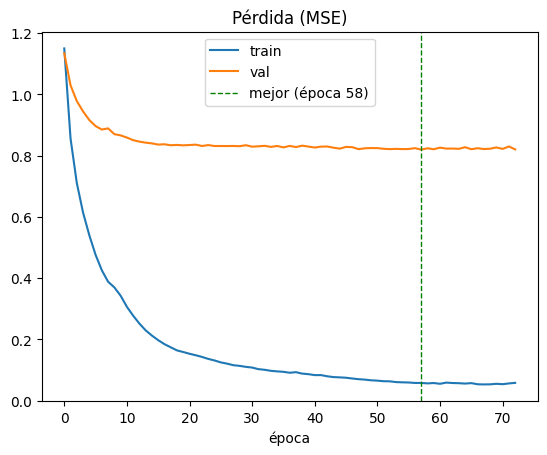

Épocas ejecutadas: 73/200
EarlyStopping detuvo en la época 73 (sin mejora en 15 épocas)
Mejor val_loss: 0.819861 en la época 58 (pesos restaurados a esa época)


In [19]:
autoencoder, encoder = build_autoencoder(INPUT_DIM, latent_dim=LATENT_DIM)
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

es = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
hist = autoencoder.fit(X_train, X_train, epochs=200, batch_size=32,
                       validation_split=0.1, callbacks=[es], verbose=0)

import matplotlib.pyplot as plt
n_run = len(hist.history["loss"])                       # épocas realmente ejecutadas
best_ep = int(np.argmin(hist.history["val_loss"])) + 1  # época del mejor val_loss
# es.stopped_epoch es 0 si NO saltó el early stopping (se agotaron las épocas).
stop_ep = (es.stopped_epoch + 1) if es.stopped_epoch else n_run

plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.axvline(best_ep - 1, color="green", ls="--", lw=1, label=f"mejor (época {best_ep})")
plt.legend(); plt.title("Pérdida (MSE)"); plt.xlabel("época"); plt.show()

print(f"Épocas ejecutadas: {n_run}/200")
if es.stopped_epoch:
    print(f"EarlyStopping detuvo en la época {stop_ep} (sin mejora en {15} épocas)")
else:
    print("EarlyStopping NO saltó: se agotaron las 200 épocas")
print(f"Mejor val_loss: {min(hist.history['val_loss']):.6f} en la época {best_ep} (pesos restaurados a esa época)")

## 6. Derivación del tracker (procedimiento FIJO)

Proyectamos cada acción al espacio latente con tu **encoder** y aplicamos el
procedimiento común `select_tracker` (clustering determinista por **similitud
coseno** → 25 representantes → pesos por tamaño de grupo). Cada representante es el
**medoide** de su grupo: el **activo real más central** (el de mayor similitud
coseno al resto de su grupo) — un caso concreto que resume al conjunto, como
visteis en la teoría. **Es idéntico al del servidor**: si lo que envías no es
coherente con tu latente, la webapp lo rechaza.

> **¿Por qué el clustering usa distancia coseno y no euclídea?** Agrupamos las
> acciones por la **dirección** de su vector latente, no por su magnitud. En réplica
> de índice, lo que hace que dos acciones se comporten igual frente al benchmark es
> **cómo co-mueven** —la *forma* de su exposición a los factores comunes—, no cuánto
> oscilan en tamaño. La **similitud coseno** mide justo eso (el ángulo entre
> embeddings, ignorando la escala) y es la distancia natural para comparar
> embeddings, como visteis en la teoría. Por eso `select_tracker` normaliza cada
> vector latente a la esfera unidad antes de aplicar k-means (*spherical k-means*).

Tracker (25 acciones):
  AFL     0.29%
  AVB     3.80%
  AZO     1.17%
  CB      3.51%
  CMI     2.05%
  CMS     5.56%
  GIS     2.92%
  LMT     1.46%
  MCK     2.34%
  PEP     7.02%
  PPL     1.17%
  PRU     3.22%
  TMO     5.26%
  TXN     3.80%
  UNH     1.46%
  UNP     1.17%
  VFC     4.68%
  VLO     0.88%
  VRSN   11.11%
  WHR     7.89%
  WYNN    7.02%
  XOM     4.09%
  XYL     9.36%
  YUM     2.63%
  ZION    6.14%


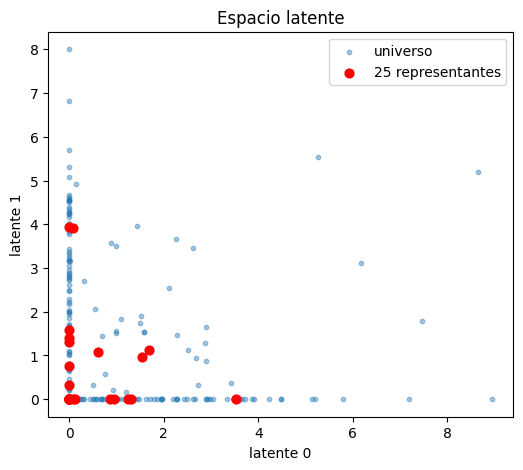

In [20]:
latent = encoder.predict(X_train, verbose=0)        # (n_acciones, latent_dim)
sel_tickers, sel_weights = select_tracker(latent, X_tickers, n_assets=meta["n_assets"])
print("Tracker (25 acciones):")
for t, w in zip(sel_tickers, sel_weights):
    print(f"  {t:6s} {w:6.2%}")

# Visualización del latente (2 primeras dimensiones) y los 25 representantes.
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(latent[:,0], latent[:,1], s=10, alpha=0.4, label="universo")
sel_idx = [X_tickers.index(t) for t in sel_tickers]
plt.scatter(latent[sel_idx,0], latent[sel_idx,1], c="red", s=40, label="25 representantes")
plt.xlabel("latente 0"); plt.ylabel("latente 1"); plt.legend(); plt.title("Espacio latente"); plt.show()

## 7. Evaluación local en validación

Antes de enviar, calcula tu tracking error en **validación** localmente (rápido, sin
saturar el servidor). Usa la **misma** definición de TE que el servidor.

In [21]:
tracker_w = dict(zip(sel_tickers, sel_weights))
tracker_returns = te.portfolio_returns(prices_wide, tracker_w)

ae_te_train = te.annualized_tracking_error(in_window(tracker_returns, train_w), in_window(rsp_returns, train_w))
ae_te_val   = te.annualized_tracking_error(in_window(tracker_returns, val_w),   in_window(rsp_returns, val_w))

# Comparativa contra el modelo base PCA, en TRAIN y VALIDACIÓN.
comparison = pd.DataFrame(
    {"TE train": [f"{ae_te_train:.2%}", f"{pca_te_train:.2%}"],
     "TE validación": [f"{ae_te_val:.2%}", f"{pca_te_val:.2%}"]},
    index=["Tu autoencoder", "PCA (base)"],
)
print("== Tu tracker vs PCA — tracking error frente a RSP ==")
display(comparison)
if ae_te_val < pca_te_val:
    print(f"✓ Bates a PCA en validación por {(pca_te_val - ae_te_val) * 100:.2f} pp. ¡Bien!")
else:
    print(f"✗ Aún no bates a PCA en validación ({ae_te_val:.2%} vs {pca_te_val:.2%}). Mejora tu AE.")

print("\n== Detalle de tu tracker vs RSP — VALIDACIÓN ==")
display(te.summary_frame(in_window(tracker_returns, val_w), in_window(rsp_returns, val_w),
                         tracker_name="Tu tracker"))
print("Suelo irreducible del universo completo ≈ 2%. ¿Bates a PCA y cuánto te acercas al suelo con tu AE?")

== Tu tracker vs PCA — tracking error frente a RSP ==


,TE train,TE validación
Tu autoencoder,4.99%,5.31%
PCA (base),4.40%,4.84%


✗ Aún no bates a PCA en validación (5.31% vs 4.84%). Mejora tu AE.

== Detalle de tu tracker vs RSP — VALIDACIÓN ==


,Tu tracker,RSP
CAGR,-1.95%,0.25%
Vol. anualizada,18.73%,18.98%
Máx. drawdown,-19.68%,-21.38%
Tracking error,5.31%,
Correlación,0.960,
Días,501,


Suelo irreducible del universo completo ≈ 2%. ¿Bates a PCA y cuánto te acercas al suelo con tu AE?


## 8. Envío a la webapp

`submit_mod.submit(...)` construye el JSON del contrato (latente + 25 acciones +
pesos) y lo envía. El servidor verifica coherencia, calcula el TE y actualiza el
leaderboard.

- **Envío normal** → evalúa en **validación** (leaderboard en vivo). **Sin límite**:
  itera aquí para probar tus modelos.
- `is_final=True` → **evaluación final irreversible** en test: congela tu modelo (es la
  única evaluación de test). Requiere `confirm_final=True`. **No verás el número antes de congelar.**

> ⚠️ **La semilla debe seguir siendo `SEED = 42`.** Si la cambias, la entrega se
> **rechaza** (en validación y en test). Todos entrenáis con la misma semilla: lo
> único que os diferencia es vuestro autoencoder.

In [22]:
# Resumen de TU arquitectura (capas, activaciones, nº de parámetros). Se envía con
# la submission para que aparezca en el leaderboard.
arch = submit_mod.architecture_summary(autoencoder)
print(f"Arquitectura: {len(arch['layers'])} capas · {arch['n_params']:,} parámetros")

# Envío normal (validación). Reenvía tantas veces como quieras durante la fase.
resp = submit_mod.submit(
    API_URL, TOKEN,
    latent_tickers=X_tickers, latent_coordinates=latent,
    tracker_tickers=sel_tickers, tracker_weights=sel_weights,
    model_metadata={"latent_dim": LATENT_DIM, "seed": SEED,
                    "n_params": arch["n_params"], "architecture": arch["layers"]},
)
print(resp)

Arquitectura: 3 capas · 1,411,762 parámetros
{'status': 'validated', 'phase': 'validation', 'tracking_error': 0.05305733249067938, 'percentile': 81.1621748043648}


In [23]:
# --- Evaluación FINAL (IRREVERSIBLE; única evaluación de test; congela tu modelo) ---
# Solo al final de la competición, con tu modelo definitivo. Adjunta la arquitectura
# (igual que en validación) para que se vea en el leaderboard de test.
# resp_final = submit_mod.submit(
#     API_URL, TOKEN,
#     latent_tickers=X_tickers, latent_coordinates=latent,
#     tracker_tickers=sel_tickers, tracker_weights=sel_weights,
#     is_final=True, confirm_final=True,
#     model_metadata={"latent_dim": LATENT_DIM, "seed": SEED,
#                     "n_params": arch["n_params"], "architecture": arch["layers"]},
# )
# print(resp_final)